In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

df_raw = pd.read_csv("../data/raw/base_operativa.csv")
df_clean = pd.read_csv("../data/processed/base_operativa_clean.csv")

df_raw.head()


,id_cliente,telefono,fecha_contacto,resultado,agente,importe,producto
0,1,+54 11 5555 6458,2024-13-04,No contesta,Juan,error,A
1,2,11-5555-7810,2024/01/11,Contactado,Ana,NaN,B
2,3,NaN,2024/01/03,Contactado,Juan,NaN,C
3,4,NaN,2024-13-25,Error,Ana,1045,B
4,5,+54 11 5555 3380,2024-01-12,No contesta,Pedro,NaN,A


In [3]:
print("Registros en base RAW:", len(df_raw))
print("Registros en base CLEAN:", len(df_clean))

df_raw.info()


Registros en base RAW: 525
Registros en base CLEAN: 299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_cliente      525 non-null    int64 
 1   telefono        412 non-null    object
 2   fecha_contacto  525 non-null    object
 3   resultado       525 non-null    object
 4   agente          440 non-null    object
 5   importe         268 non-null    object
 6   producto        525 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.8+ KB


In [4]:
print("Nulos por columna:")
print(df_raw.isna().sum())

print("\nDuplicados:", df_raw.duplicated().sum())

Nulos por columna:
id_cliente          0
telefono          113
fecha_contacto      0
resultado           0
agente             85
importe           257
producto            0
dtype: int64

Duplicados: 25


In [5]:
df_raw["resultado"].value_counts(dropna=False)

resultado
No contesta          96
Contactado           93
No contesta          91
Error                86
Contactado           80
Fuera de servicio    79
Name: count, dtype: int64

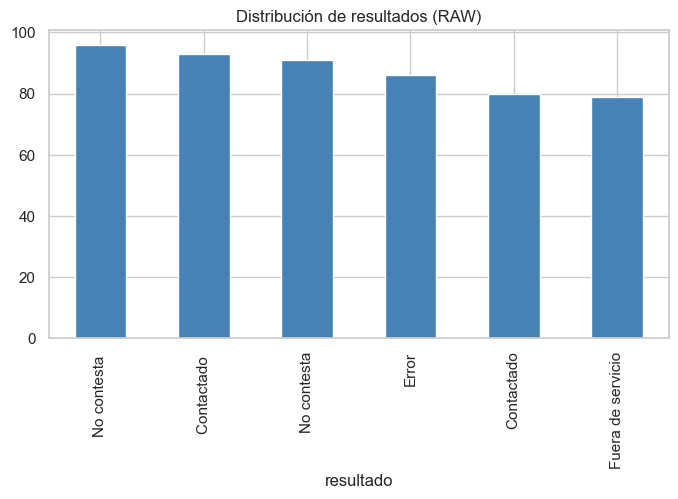

In [6]:
plt.figure(figsize=(8,4))
df_raw["resultado"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribución de resultados (RAW)")
plt.show()

In [7]:
df_raw["agente"].value_counts(dropna=False)

agente
Pedro     98
Marcos    95
Lucía     86
NaN       85
Ana       83
Juan      78
Name: count, dtype: int64

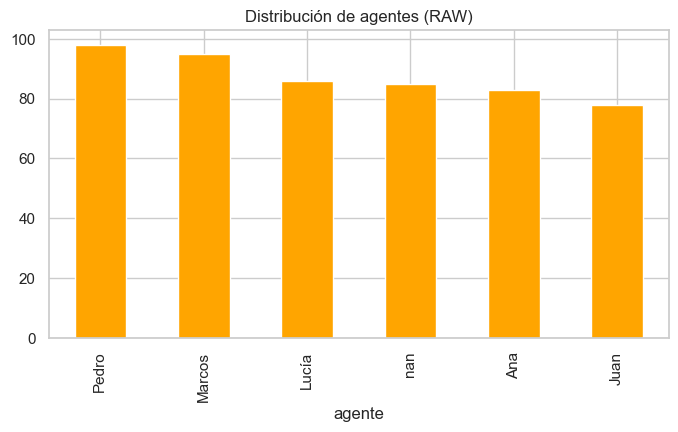

In [8]:
plt.figure(figsize=(8,4))
df_raw["agente"].value_counts(dropna=False).plot(kind="bar", color="orange")
plt.title("Distribución de agentes (RAW)")
plt.show()

In [9]:
def es_fecha_valida(fecha):
    try:
        pd.to_datetime(fecha, errors="raise")
        return True
    except:
        return False

df_raw["fecha_valida"] = df_raw["fecha_contacto"].apply(es_fecha_valida)
df_raw["fecha_valida"].value_counts()

C:\Users\Rodrigo Lukojc\AppData\Local\Temp\ipykernel_40536\2552610331.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(fecha, errors="raise")


fecha_valida
True     398
False    127
Name: count, dtype: int64

In [10]:
df_raw[df_raw["fecha_valida"] == False].head()

,id_cliente,telefono,fecha_contacto,resultado,agente,importe,producto,fecha_valida
0,1,+54 11 5555 6458,2024-13-04,No contesta,Juan,error,A,False
3,4,NaN,2024-13-25,Error,Ana,1045,B,False
7,8,1155553268,2024-13-30,No contesta,NaN,NaN,C,False
8,9,11-5555-4793,2024-13-22,Contactado,Juan,1082,A,False
9,10,NaN,2024-13-15,Contactado,Lucía,NaN,C,False


In [11]:
print("Registros RAW:", len(df_raw))
print("Registros CLEAN:", len(df_clean))
print("Registros eliminados:", len(df_raw) - len(df_clean))

Registros RAW: 525
Registros CLEAN: 299
Registros eliminados: 226


In [12]:
df_clean.head()

,id_cliente,telefono,fecha_contacto,resultado,agente,importe,producto
0,2,1155557810,2024-01-11,Contactado,Ana,NaN,B
1,5,541155553380,2024-01-12,No contesta,Pedro,NaN,A
2,6,1155558829,2024-01-21,Error,SIN_ASIGNAR,NaN,B
3,11,541155556080,2024-01-28,Contactado,Pedro,NaN,A
4,15,1155551636,2024-01-08,Fuera de servicio,Pedro,NaN,A


📊 Análisis Exploratorio de Datos (EDA)
Contact Center Data Cleaning
Autor: Rodrigo Lukojc
Proyecto: Limpieza, normalización y análisis de datos operativos de un Contact Center
Notebook: Exploratory Data Analysis (EDA)

📝 Objetivo del notebook
Este notebook realiza un análisis exploratorio de la base operativa original generada para el proyecto.
El objetivo es:

Identificar problemas de calidad de datos

Detectar nulos, duplicados y formatos inconsistentes

Analizar la distribución de resultados y agentes

Validar fechas y teléfonos

Comparar la base original vs la base CLEAN procesada por el script cleaning.py

Este EDA sirve como diagnóstico previo al proceso de limpieza y como evidencia visual del trabajo realizado.